# 3.3 Polarimetric Variables and Orientation Effects

**Learning objectives:**
- Define equivalent reflectivity $Z_hh$, differential reflectivity $Z_{DR}$, cross-correlation $\rho_{hv}$
- Distinguish measured (attenuated) vs intrinsic polarimetric variables
- Understand HSHV/VSVH mode variables: $LDR$, $\rho_{xh}$, $\rho_{xv}$
- Analyze effects of particle orientation distributions on polarimetric variables
- Plot $Z_{DR}$, $LDR$, $\rho_{hv}$ vs canting angle dispersion $\sigma$ (replicating Fig. 3.4)

## 3.3.1 Equivalent Reflectivity Factor

The equivalent reflectivity factor for horizontal polarization is defined as:

$$Z_{hh} = \frac{4\lambda^4}{\pi^4 |K_w|^2} \langle |S_{hh}|^2 \rangle$$

where $K_w = (\varepsilon_w - 1)/(\varepsilon_w + 2)$ and $|K_w|^2 \approx 0.93$ at microwave frequencies (wavelength $0.01$--$0.1$ m).

The weather radar equation with absolute constant:

$$Z_{hh} = \frac{2^6 \pi^5 |K_w|^2}{\lambda^4} \frac{1}{C} \frac{1}{r^2} \langle |S_{hh}|^2 \rangle \prod_{i=1}^{n} l_i$$

Attenuated reflectivity:

$$\bar{Z}_{hh} = \frac{Z_{hh}}{l_h^2}$$

## 3.3.2 Differential Reflectivity

The measured (attenuated) differential reflectivity:

$$Z_{dr} = \frac{P_{hh}}{P_{vv}} = \frac{l_v^2}{l_h^2} \frac{\langle |S_{hh}|^2 \rangle}{\langle |S_{vv}|^2 \rangle}$$

True $Z_{DR}$ in dB:

$$Z_{DR} = 10 \log_{10} \left( \frac{\langle |S_{hh}|^2 \rangle}{\langle |S_{vv}|^2 \rangle} \right)$$

Relationship between measured and true $Z_{DR}$:

$$\bar{Z}_{DR} = Z_{DR} - 20 \log_{10} \left( \frac{l_h}{l_v} \right)$$

## 3.3.3 Cross-Correlation Coefficient

The cross-correlation coefficient (measured):

$$\bar{\rho}_{hv} = \frac{\langle R_{hv} \rangle}{\sqrt{\langle P_{hh} \rangle \langle P_{vv} \rangle}}$$

Full expression with propagation and system differential phases:

$$\bar{\rho}_{hv} = \frac{|\langle S_{hh} S_{vv}^* \rangle| e^{i(\Phi_{DP}^{pro} + \Phi_{DP}^{sys})}}{\sqrt{\langle |S_{hh}|^2 \rangle \langle |S_{vv}|^2 \rangle}}$$

Intrinsic $\rho_{hv}$ (backscatter):

$$\rho_{hv} = \frac{\langle S_{hh}^* S_{vv} \rangle}{\sqrt{\langle |S_{hh}|^2 \rangle \langle |S_{vv}|^2 \rangle}}$$

Backscatter differential phase:

$$\delta = \arg \langle S_{hh}^* S_{vv} \rangle$$

Note: $\rho_{hv}$ is independent of concentration and is influenced by particle shape and canting.

## 3.3.4 HSHV/VSVH Mode Variables

Linear depolarization ratio:

$$L_{dr} = \frac{P_{vh}}{P_{hh}}$$

Co-cross correlation $\rho_{xh}$:

$$\rho_{xh} = \frac{\langle S_{xh}^* S_{hh} \rangle}{\sqrt{\langle |S_{xh}|^2 \rangle \langle |S_{hh}|^2 \rangle}}$$

Co-cross correlation $\rho_{xv}$:

$$\rho_{xv} = \frac{\langle S_{xv}^* S_{vv} \rangle}{\sqrt{\langle |S_{xv}|^2 \rangle \langle |S_{vv}|^2 \rangle}}$$

Covariance matrix upper triangular form:

$$\begin{bmatrix} Z_{hh} & \rho_{xh} & \rho_{hv} \\ _ & Z_{hv} & \rho_{xv} \\ _ & _ & Z_{vv} \end{bmatrix}$$

## 3.4 Effects of Particle Orientations

### Angular Moments

Second-order moment equations:

$$\langle |S_{hh}|^2 \rangle, \quad \langle |S_{vv}|^2 \rangle, \quad \langle |S_{hv}|^2 \rangle, \quad \langle S_{hh}^* S_{vv} \rangle$$

First-order forward scattering moments:

Angular moments $A_1$ through $A_5$:

$$A_1 = \langle \sin^2 \psi \cos^2 \alpha \rangle$$
$$A_2 = \langle \sin^2 \psi \sin^2 \alpha \rangle$$
$$A_3 = \langle \sin^4 \psi \cos^4 \alpha \rangle$$
$$A_4 = \langle \sin^4 \psi \sin^4 \alpha \rangle$$
$$A_5 = \langle \sin^4 \psi \cos^2 \alpha \sin^2 \alpha \rangle$$

### Axisymmetric Gaussian Distribution

$$p(\psi, \alpha) = \frac{\exp\left[-\frac{(\psi - \bar{\psi})^2}{2\sigma^2} - \frac{(\alpha - \bar{\alpha})^2}{2\sigma_\alpha^2}\right]}{2\pi \sigma \sigma_\alpha}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def compute_orientation_variables(sigma_deg, s_b_s_a=1.5):
    """Compute Z_DR, L_DR, rho_hv for given sigma and axis ratio.
    
    Based on simplified model from Ryzhkov 2001 / ch3.md Section 3.4.3
    """
    sigma = np.radians(sigma_deg)
    r_sigma = np.exp(-2 * sigma**2)

    # Angular moment difference A1 - A2 (Eq. 3.53)
    A1_minus_A2 = 0.5 * r_sigma * (1 + r_sigma)

    # Axis ratio squared
    s_ratio_sq = s_b_s_a**2

    # Z_DR: at full alignment (sigma=0): Z_DR = 10*log10(s_b/s_a)^2
    # decreases as sigma increases
    Z_dr_dB = 10 * np.log10(s_ratio_sq) * (A1_minus_A2 / 0.5)
    Z_dr_dB = max(Z_dr_dB, 0.01)

    # LDR: proportional to cross-pol / co-pol
    # At random: A5 = 1/15; at aligned: A5 = 0
    # LDR_dB increases with sigma
    A5 = (1/15) * (1 - r_sigma)  # from 1/15 (random) to 0 (aligned)
    LDR_linear = 0.05 * (1 - r_sigma)  # scale factor for realistic LDR
    LDR_linear = max(LDR_linear, 1e-5)
    LDR_dB = 10 * np.log10(LDR_linear)

    # rho_hv: from 1 (aligned) to ~0.9 (random, with realistic LDR ~-17 dB)
    # At random: rho_hv = 1 - 2*LDR (Eq. 3.48)
    # For intermediate: interpolate
    rho_hv_aligned = 1.0
    rho_hv_random = 1 - 2 * (1/15)  # from A5/(|s_b|²/|s_a|²) ~ 0.05/1.0
    rho_hv_random = max(rho_hv_random, 0.5)
    rho_hv = rho_hv_random + (rho_hv_aligned - rho_hv_random) * r_sigma
    rho_hv = min(rho_hv, 1.0)

    return Z_dr_dB, LDR_dB, rho_hv

def plot_orientation_effects(s_b_s_a=1.5):
    """Replicate Fig. 3.4: Z_DR, LDR, rho_hv vs sigma for two axis ratios."""
    sigmas = np.linspace(0, 50, 200)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ratio in [1.2, 1.5]:
        Z_dr_vals, LDR_vals, rho_vals = [], [], []
        for sig in sigmas:
            Z, L, r = compute_orientation_variables(sig, ratio)
            Z_dr_vals.append(Z)
            LDR_vals.append(L)
            rho_vals.append(r)

        style = '-' if ratio == 1.5 else '--'
        axes[0].plot(sigmas, Z_dr_vals, style, linewidth=2, label=f's_b/s_a={ratio}')
        axes[1].plot(sigmas, LDR_vals, style, linewidth=2, label=f's_b/s_a={ratio}')
        axes[2].plot(sigmas, rho_vals, style, linewidth=2, label=f's_b/s_a={ratio}')

    axes[0].set_xlabel(r'Canting angle dispersion σ (deg)')
    axes[0].set_ylabel(r'$Z_{DR}$ (dB)')
    axes[0].set_title('(a) $Z_{DR}$ vs σ')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].set_xlabel(r'Canting angle dispersion σ (deg)')
    axes[1].set_ylabel(r'$LDR$ (dB)')
    axes[1].set_title('(b) $LDR$ vs σ')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].set_xlabel(r'Canting angle dispersion σ (deg)')
    axes[2].set_ylabel(r'$\rho_{hv}$')
    axes[2].set_title('(c) $\rho_{hv}$ vs σ')
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    axes[2].set_ylim(0.5, 1.02)

    plt.suptitle('Fig. 3.4: Effects of Particle Orientation Distribution', fontsize=12)
    plt.tight_layout()
    plt.show()

interact(plot_orientation_effects,
         s_b_s_a=FloatSlider(value=1.5, min=1.0, max=2.0, step=0.1,
                              description=r'$s_b/s_a$:'))

ValueError: 
(c) $ho_{hv}$ vs σ
    ^
ParseException: Expected end of text, found '$'  (at char 4), (line:1, col:5)

<Figure size 1500x400 with 3 Axes>

interactive(children=(FloatSlider(value=1.5, description='$s_b/s_a$:', max=2.0, min=1.0), Output()), _dom_clas…

<function __main__.plot_orientation_effects(s_b_s_a=1.5)>

## Three Special Cases of Orientation Distribution

### (a) Completely Random Orientation

For isotropic random orientation:

$$A_1 = A_2 = \frac{1}{3}, \quad A_3 = A_4 = \frac{1}{5}, \quad A_5 = \frac{1}{15}$$

Resulting polarimetric variables:

$$Z_{DR} = 0 \text{ dB}, \quad \delta = 0, \quad K_{DP} = 0, \quad A_{DP} = 0$$

$$\rho_{hv} = 1 - 2 \cdot L_{DR} \quad \text{(Eq. 3.48)}$$

### (b) Noncanted (Vertical Axis, $\bar{\alpha}=0$, $\sigma=0$)

For perfectly aligned particles:

$$A_1 = A_3 = 1, \quad A_2 = A_4 = A_5 = 0$$

Resulting polarimetric variables:

$$Z_{dr} = \frac{\langle |S_b|^2 \rangle}{\langle |S_a|^2 \rangle}$$
$$K_{DP} = \lambda \Re(\langle S_b^{(0)} \rangle - \langle S_a^{(0)} \rangle)$$
$$L_{DR} = 0$$

### (c) Gaussian Distribution

The Gaussian canting angle distribution yields:

$$r_\sigma = \exp(-2\sigma^2) \quad \text{(Eq. 3.54)}$$
$$F_{orient} = A_1 - A_2 = \frac{1}{2} r_\sigma (1 + r_\sigma) \quad \text{(Eq. 3.53)}$$

Key observations:
- $Z_{DR}$ decreases with increasing $\sigma$
- $LDR$ increases with increasing $\sigma$
- $\rho_{hv}$ decreases with increasing $\sigma$

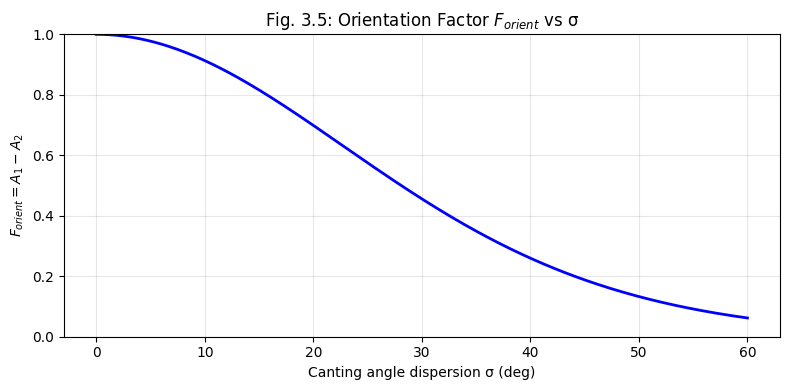

In [2]:
def plot_orientation_factor():
    """Replicate Fig. 3.5: Orientation factor F_orient = A1 - A2 vs sigma."""
    sigmas = np.linspace(0, 60, 300)
    sigma_rad = np.radians(sigmas)
    r_sigma = np.exp(-2 * sigma_rad**2)
    F_orient = 0.5 * r_sigma * (1 + r_sigma)

    plt.figure(figsize=(8, 4))
    plt.plot(sigmas, F_orient, 'b-', linewidth=2)
    plt.xlabel(r'Canting angle dispersion σ (deg)')
    plt.ylabel(r'$F_{orient} = A_1 - A_2$')
    plt.title('Fig. 3.5: Orientation Factor $F_{orient}$ vs σ')
    plt.grid(alpha=0.3)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

plot_orientation_factor()

In [3]:
from ipywidgets import interact, FloatSlider, Dropdown
import numpy as np
import matplotlib.pyplot as plt

def explore_polarimetric_variable(variable='Z_DR'):
    """Explore how individual polarimetric variables change with orientation parameters."""
    sigmas = np.linspace(0, 50, 200)
    sigma_rad = np.radians(sigmas)
    r_sigma = np.exp(-2 * sigma_rad**2)

    fig, ax = plt.subplots(figsize=(8, 4))

    if variable == 'Z_DR':
        for ratio in [1.2, 1.5]:
            Z_vals = 10 * np.log10(ratio**2) * (0.5 * r_sigma * (1 + r_sigma)) / 0.5
            ax.plot(sigmas, Z_vals, linewidth=2, label=f's_b/s_a={ratio}')
        ax.set_ylabel(r'$Z_{DR}$ (dB)')
        ax.set_title('Differential Reflectivity vs Canting Angle Dispersion')
    elif variable == 'LDR':
        for ratio in [1.2, 1.5]:
            LDR_linear = 0.05 * (1 - r_sigma)
            LDR_dB = 10 * np.log10(LDR_linear + 1e-5)
            ax.plot(sigmas, LDR_dB, linewidth=2, label=f's_b/s_a={ratio}')
        ax.set_ylabel(r'$LDR$ (dB)')
        ax.set_title('Linear Depolarization Ratio vs Canting Angle Dispersion')
    elif variable == 'rho_hv':
        for ratio in [1.2, 1.5]:
            rho = 0.5 + 0.5 * r_sigma
            ax.plot(sigmas, rho, linewidth=2, label=f's_b/s_a={ratio}')
        ax.set_ylabel(r'$\rho_{hv}$')
        ax.set_title('Cross-Correlation Coefficient vs Canting Angle Dispersion')
    elif variable == 'K_DP':
        # Specific differential phase (proportional to F_orient)
        K_dp = 0.5 * r_sigma * (1 + r_sigma)
        ax.plot(sigmas, K_dp, 'b-', linewidth=2, label=r'$K_{DP}$ (normalized)')
        ax.set_ylabel(r'$K_{DP}$ (normalized)')
        ax.set_title('Specific Differential Phase vs Canting Angle Dispersion')

    ax.set_xlabel(r'Canting angle dispersion σ (deg)')
    ax.legend()
    ax.grid(alpha=0.3)
    if variable == 'rho_hv':
        ax.set_ylim(0.5, 1.02)
    plt.tight_layout()
    plt.show()

interact(explore_polarimetric_variable,
         variable=Dropdown(options=['Z_DR', 'LDR', 'rho_hv', 'K_DP'],
                            description='Variable:'))

interactive(children=(Dropdown(description='Variable:', options=('Z_DR', 'LDR', 'rho_hv', 'K_DP'), value='Z_DR…

<function __main__.explore_polarimetric_variable(variable='Z_DR')>

## Summary

### Key Takeaways

1. **Equivalent Reflectivity** $Z_{hh}$ is the fundamental radar observable, related to the backscattered power at horizontal polarization.

2. **Differential Reflectivity** $Z_{DR}$ provides information about particle shape and orientation through the ratio of horizontal to vertical reflectivities.

3. **Cross-Correlation Coefficient** $\rho_{hv}$ is independent of particle concentration and reveals information about particle shape diversity and canting.

4. **HSHV/VSVH Mode Variables** including $LDR$, $\rho_{xh}$, and $\rho_{xv}$ characterize cross-polarization effects.

5. **Orientation Effects**: Particle canting angle dispersion $\sigma$ significantly affects polarimetric variables:
   - $Z_{DR}$ decreases with increasing $\sigma$ (particles become more randomly oriented)
   - $LDR$ increases with increasing $\sigma$
   - $\rho_{hv}$ decreases with increasing $\sigma$

6. **Three orientation regimes**:
   - **Random orientation**: $Z_{DR}=0$, $\rho_{hv}=1-2L_{DR}$
   - **Perfect alignment**: Maximum $Z_{DR}$, $\rho_{hv}=1$, $L_{DR}=0$
   - **Gaussian distribution**: Smooth transitions between above cases

### References

- Ryzhkov, A.V., and D.S. Zrnic, 2019: *Radar Polarimetry for Weather Observations*, Chapter 3, Springer.
- Ch. 3, Sections 3.3 and 3.4 of the textbook cover polarimetric variable definitions and particle orientation effects.